In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/kaggle/input/world-bank-data-2025/world_bank_data_2025.csv")
df

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP)
0,Aruba,aw,2010,2.078141,2.453597e+09,24093.140151,NaN,11.666131,-1.223407,-2.733457,-18.752537,NaN,NaN,NaN,2.313385e+09,NaN
1,Aruba,aw,2011,4.316297,2.637859e+09,25712.384302,NaN,4.801974,4.005674,3.369237,-9.877656,NaN,NaN,NaN,2.391841e+09,NaN
2,Aruba,aw,2012,0.627472,2.615208e+09,25119.665545,NaN,8.200875,0.184033,-1.040800,3.473451,NaN,NaN,NaN,2.499118e+09,NaN
3,Aruba,aw,2013,-2.372065,2.727850e+09,25813.576727,NaN,10.709709,-1.995948,6.431483,-11.813206,NaN,NaN,NaN,2.563517e+09,NaN
4,Aruba,aw,2014,0.421441,2.790850e+09,26129.839062,NaN,3.213869,3.958897,-1.586575,-4.658577,NaN,NaN,NaN,2.688102e+09,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3467,Zimbabwe,zw,2021,98.546105,2.724052e+10,1724.387731,9.540,-31.795551,113.294981,8.468017,1.278300,NaN,NaN,NaN,2.662178e+10,NaN
3468,Zimbabwe,zw,2022,104.705171,3.278975e+10,2040.552459,10.087,-36.833393,266.987152,6.139263,0.930064,NaN,NaN,NaN,3.202694e+10,NaN
3469,Zimbabwe,zw,2023,NaN,3.523137e+10,2156.034004,8.759,-73.540441,921.535652,5.336730,0.379995,NaN,NaN,NaN,3.479607e+10,NaN
3470,Zimbabwe,zw,2024,NaN,NaN,NaN,8.554,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3472 entries, 0 to 3471
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country_name                     3472 non-null   object 
 1   country_id                       3472 non-null   object 
 2   year                             3472 non-null   int64  
 3   Inflation (CPI %)                2694 non-null   float64
 4   GDP (Current USD)                2933 non-null   float64
 5   GDP per Capita (Current USD)     2938 non-null   float64
 6   Unemployment Rate (%)            2795 non-null   float64
 7   Interest Rate (Real, %)          1735 non-null   float64
 8   Inflation (GDP Deflator, %)      2904 non-null   float64
 9   GDP Growth (% Annual)            2912 non-null   float64
 10  Current Account Balance (% GDP)  2563 non-null   float64
 11  Government Expense (% of GDP)    1820 non-null   float64
 12  Government Revenue (

In [4]:
df.isnull().sum()

country_name                          0
country_id                            0
year                                  0
Inflation (CPI %)                   778
GDP (Current USD)                   539
GDP per Capita (Current USD)        534
Unemployment Rate (%)               677
Interest Rate (Real, %)            1737
Inflation (GDP Deflator, %)         568
GDP Growth (% Annual)               560
Current Account Balance (% GDP)     909
Government Expense (% of GDP)      1652
Government Revenue (% of GDP)      1643
Tax Revenue (% of GDP)             1639
Gross National Income (USD)         676
Public Debt (% of GDP)             2620
dtype: int64

In [5]:
df.drop(['Public Debt (% of GDP)'] , axis=1 , inplace=True)
df.drop(['Tax Revenue (% of GDP)'] , axis=1 , inplace=True)
df.drop(['Government Revenue (% of GDP)'] , axis=1 , inplace=True)
df.drop(['Government Expense (% of GDP)'] , axis=1 , inplace=True)

In [6]:
df.isnull().sum()

country_name                          0
country_id                            0
year                                  0
Inflation (CPI %)                   778
GDP (Current USD)                   539
GDP per Capita (Current USD)        534
Unemployment Rate (%)               677
Interest Rate (Real, %)            1737
Inflation (GDP Deflator, %)         568
GDP Growth (% Annual)               560
Current Account Balance (% GDP)     909
Gross National Income (USD)         676
dtype: int64

In [7]:
df[df['Inflation (CPI %)'].isna()].head(50)

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Gross National Income (USD)
10,Aruba,aw,2020,NaN,2.481857e+09,22855.932320,NaN,7.825935,-0.951473,-26.211821,-12.750754,2.413702e+09
11,Aruba,aw,2021,NaN,2.929447e+09,27200.061079,NaN,11.897084,-4.912625,24.132627,2.705530,2.824767e+09
12,Aruba,aw,2022,NaN,3.279344e+09,30559.533535,NaN,2.852654,3.157279,8.517918,7.030547,3.154132e+09
13,Aruba,aw,2023,NaN,3.648573e+09,33984.790620,NaN,-0.852278,6.709461,4.263719,5.330807,3.332806e+09
14,Aruba,aw,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,Aruba,aw,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,Afghanistan,af,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,Angola,ao,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63,Albania,al,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,Andorra,ad,2010,NaN,3.449926e+09,42746.830953,NaN,NaN,0.374314,-1.974958,NaN,NaN


In [8]:
df['year'].agg(['min' , 'max'])

min    2010
max    2025
Name: year, dtype: int64

In [9]:
df['Inflation (CPI %)'].fillna(8.93 , inplace=True)
df['GDP per Capita (Current USD)'].fillna(11329.41 , inplace=True)
df['Interest Rate (Real, %)'].fillna(3.48 , inplace=True)
df['Unemployment Rate (%)'].fillna(9.49 , inplace=True)
df['Inflation (GDP Deflator, %)'].fillna(20.55 , inplace=True)
df["GDP (Current USD)"].fillna(13560880000, inplace=True)
df["Gross National Income (USD)"].fillna(13237590000, inplace=True)
df['Current Account Balance (% GDP)'].fillna(-3.24 , inplace=True)
df['GDP Growth (% Annual)'].fillna(3.05 , inplace=True)

In [10]:
df.describe()

,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Gross National Income (USD)
count,3472.000000,3472.000000,3.472000e+03,3472.000000,3472.000000,3472.000000,3472.000000,3472.000000,3472.000000,3.472000e+03
mean,2017.500000,6.837459,3.369946e+11,17383.184057,8.162649,4.441971,8.911304,2.885231,-2.592784,3.361515e+11
std,4.610436,17.412359,1.613735e+12,25246.321857,5.390919,6.951871,24.167911,5.544441,11.811678,1.622830e+12
min,2010.000000,-6.687321,3.210541e+07,193.007146,0.100000,-81.132121,-28.760135,-54.336155,-60.877754,5.107533e+07
25%,2013.750000,1.880163,8.790270e+09,3041.026633,4.120000,3.480000,1.595996,1.449744,-5.250706,1.120315e+10
50%,2017.500000,4.686675,1.510200e+10,10224.100890,7.670000,3.480000,4.366684,3.050000,-3.240000,1.458885e+10
75%,2021.250000,8.930000,1.028211e+11,19079.136334,9.490000,5.077963,13.553388,4.877890,-0.214290,9.638831e+10
max,2025.000000,557.201817,2.772071e+13,256580.515123,35.359000,61.882604,921.535652,86.826748,235.750605,2.757614e+13


In [11]:
country_mean = df.pivot_table(index='country_name' , values='Unemployment Rate (%)' , aggfunc='mean')
country_mean

,Unemployment Rate (%)
country_name,
Afghanistan,10.410500
Albania,13.000625
Algeria,11.335750
American Samoa,9.490000
Andorra,9.490000
...,...
Virgin Islands (U.S.),12.468063
West Bank and Gaza,20.501687
"Yemen, Rep.",15.854875


In [12]:
country_mean['Unemployment Rate (%)'].agg(['min' , 'max'])

min     0.79975
max    27.03700
Name: Unemployment Rate (%), dtype: float64

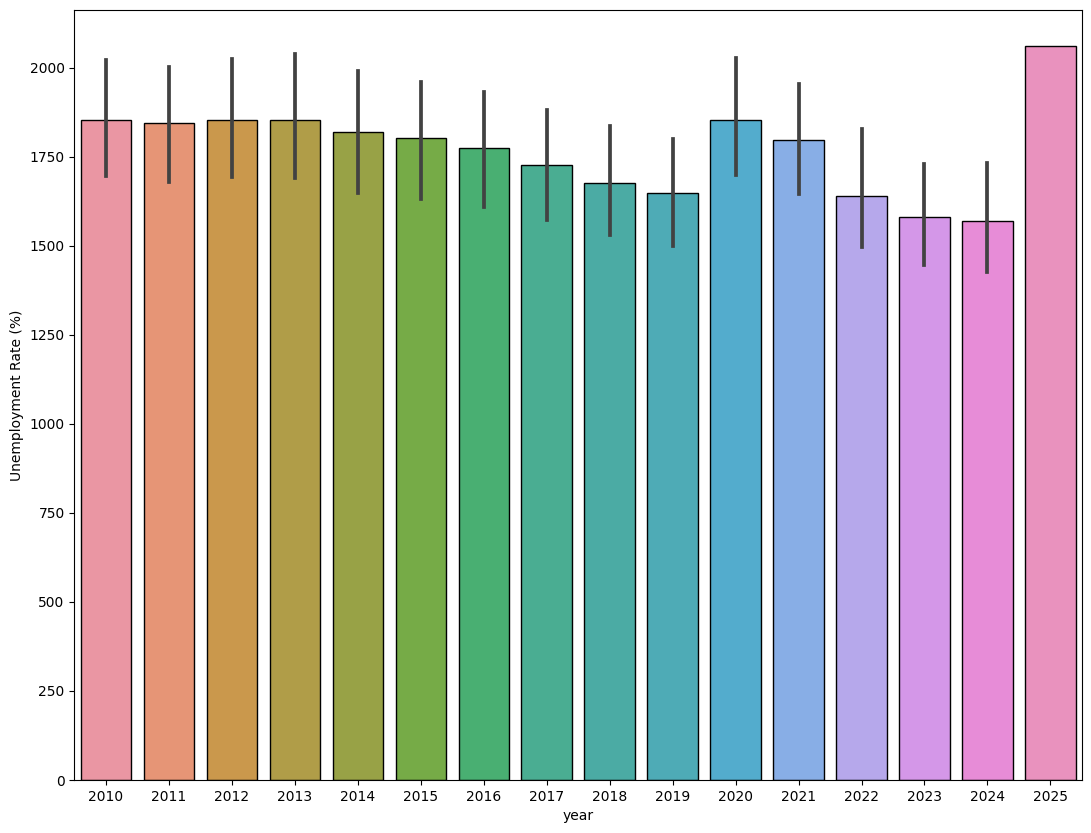

In [13]:
plt.figure(figsize=(13,10))
sns.barplot(data=df , x='year' , y='Unemployment Rate (%)' , edgecolor='black' , estimator=sum)
plt.show()

In [14]:
df

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Gross National Income (USD)
0,Aruba,aw,2010,2.078141,2.453597e+09,24093.140151,9.490,11.666131,-1.223407,-2.733457,-18.752537,2.313385e+09
1,Aruba,aw,2011,4.316297,2.637859e+09,25712.384302,9.490,4.801974,4.005674,3.369237,-9.877656,2.391841e+09
2,Aruba,aw,2012,0.627472,2.615208e+09,25119.665545,9.490,8.200875,0.184033,-1.040800,3.473451,2.499118e+09
3,Aruba,aw,2013,-2.372065,2.727850e+09,25813.576727,9.490,10.709709,-1.995948,6.431483,-11.813206,2.563517e+09
4,Aruba,aw,2014,0.421441,2.790850e+09,26129.839062,9.490,3.213869,3.958897,-1.586575,-4.658577,2.688102e+09
...,...,...,...,...,...,...,...,...,...,...,...,...
3467,Zimbabwe,zw,2021,98.546105,2.724052e+10,1724.387731,9.540,-31.795551,113.294981,8.468017,1.278300,2.662178e+10
3468,Zimbabwe,zw,2022,104.705171,3.278975e+10,2040.552459,10.087,-36.833393,266.987152,6.139263,0.930064,3.202694e+10
3469,Zimbabwe,zw,2023,8.930000,3.523137e+10,2156.034004,8.759,-73.540441,921.535652,5.336730,0.379995,3.479607e+10
3470,Zimbabwe,zw,2024,8.930000,1.356088e+10,11329.410000,8.554,3.480000,20.550000,3.050000,-3.240000,1.323759e+10


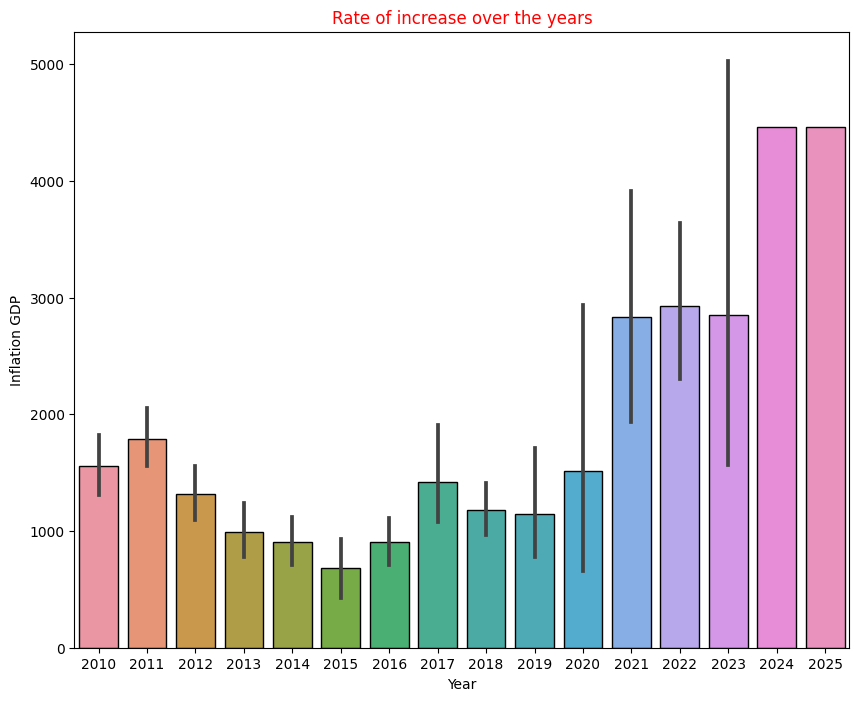

In [15]:
plt.figure(figsize=(10,8))
sns.barplot(data=df ,
            x='year' ,
            y='Inflation (GDP Deflator, %)' ,
            estimator=sum ,
            edgecolor='black'
)

plt.title("Rate of increase over the years" , color='red')
plt.xlabel("Year")
plt.ylabel("Inflation GDP")
plt.show()

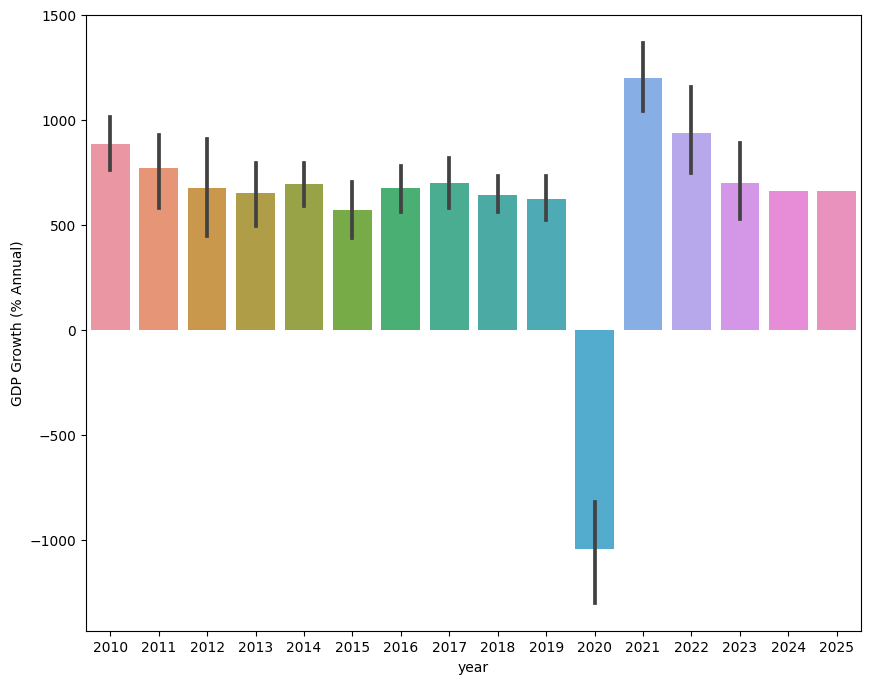

In [16]:
plt.figure(figsize=(10,8))
sns.barplot(data=df , x="year", y="GDP Growth (% Annual)",estimator=sum)
plt.show()

In [17]:
df2 = df[(df['GDP Growth (% Annual)'] < 0) & (df['year'] == 2020)]
df2

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Gross National Income (USD)
10,Aruba,aw,2020,8.930000,2.481857e+09,22855.932320,9.490,7.825935,-0.951473,-26.211821,-12.750754,2.413702e+09
26,Afghanistan,af,2020,5.601888,1.995593e+10,510.787063,11.710,3.480000,6.962946,-2.351101,-15.718303,2.010516e+10
42,Angola,ao,2020,22.271539,4.850156e+10,1449.922867,16.690,8.028657,10.763105,-5.638215,1.797711,4.414504e+10
58,Albania,al,2020,1.620887,1.524146e+10,5370.778623,11.690,6.077273,0.041065,-3.313716,-8.625047,1.499123e+10
74,Andorra,ad,2020,8.930000,2.891001e+09,37361.090067,9.490,3.480000,1.113786,-11.183940,15.526431,3.268596e+09
...,...,...,...,...,...,...,...,...,...,...,...,...
3386,Samoa,ws,2020,-1.568912,8.688984e+08,4099.660091,7.435,7.390954,1.223609,-3.108444,-8.715822,8.383668e+08
3402,Kosovo,xk,2020,0.198228,7.717145e+09,4310.888247,9.490,3.480000,1.381107,-5.340275,-7.011742,7.904028e+09
3434,South Africa,za,2020,3.232388,3.379747e+11,5580.603831,29.217,2.198414,5.391394,-6.168918,2.003523,3.323488e+11
3450,Zambia,zm,2020,15.733060,1.813776e+10,951.644317,6.033,-3.893032,13.913871,-2.785055,11.790957,1.762879e+10


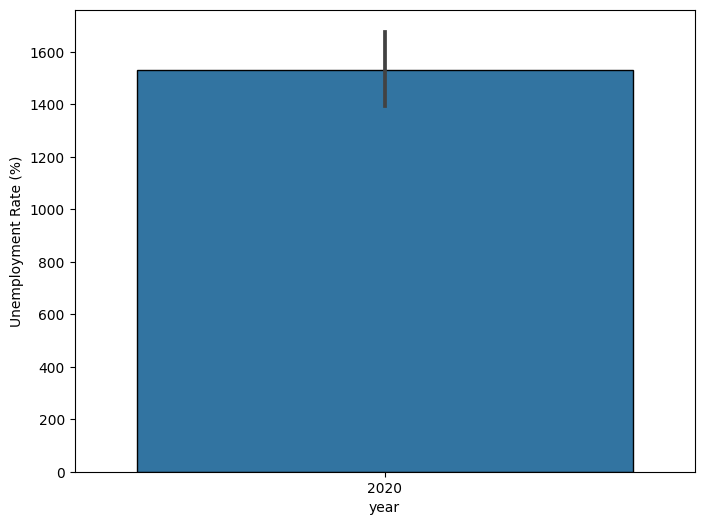

In [18]:
plt.figure(figsize=(8,6))
sns.barplot(data=df2 , x='year' , y='Unemployment Rate (%)' , edgecolor='black' , estimator=sum)
plt.show()

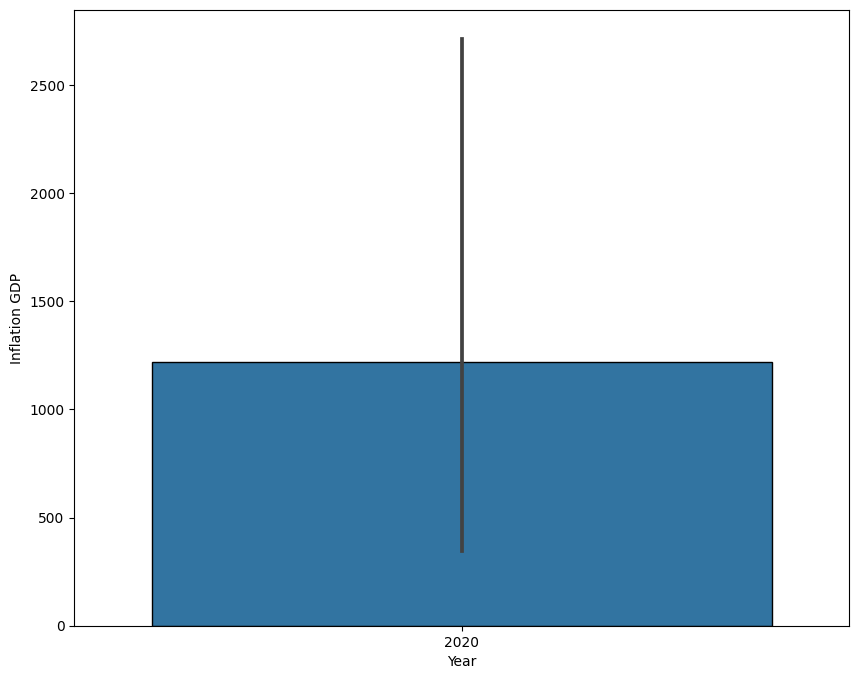

In [19]:
plt.figure(figsize=(10,8))
sns.barplot(data=df2 ,
            x='year' ,
            y='Inflation (GDP Deflator, %)' ,
            estimator=sum ,
            edgecolor='black'
)

plt.xlabel("Year")
plt.ylabel("Inflation GDP")
plt.show()

In [20]:
df3 = df.loc[df.groupby('year')['Unemployment Rate (%)'].idxmin()]
df3

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Gross National Income (USD)
2608,Qatar,qa,2010,-2.425257,1.251223e+11,77387.326789,0.450,0.273060,6.979330,19.592332,-3.240000,1.121786e+11
2257,Niger,ne,2011,2.942385,8.772951e+09,510.759562,0.316,1.235252,3.971605,2.357757,-16.333542,9.327273e+09
2610,Qatar,qa,2012,2.315349,1.868335e+11,108470.378825,0.480,-0.892371,6.329962,4.730012,33.184725,1.747088e+11
3043,Thailand,th,2013,2.184886,4.203337e+11,6018.082447,0.249,3.224335,1.778746,2.687496,-2.101535,3.934675e+11
2612,Qatar,qa,2014,3.349721,2.062246e+11,95840.631009,0.200,6.543701,-1.482751,5.334323,23.959261,1.969240e+11
2613,Qatar,qa,2015,1.814077,1.617400e+11,68985.294696,0.170,39.489373,-25.129807,4.753346,8.501810,1.581746e+11
2614,Qatar,qa,2016,2.676592,1.517322e+11,61253.637548,0.150,14.301156,-8.976699,3.064192,-5.450067,1.506228e+11
2615,Qatar,qa,2017,0.394879,1.610991e+11,63279.855695,0.140,-2.867712,7.787570,-1.497605,3.988569,1.606796e+11
2616,Qatar,qa,2018,0.255815,1.833350e+11,71039.849058,0.110,-6.612819,12.414404,1.234872,9.082937,1.795896e+11
2617,Qatar,qa,2019,-0.666641,1.763713e+11,66841.301347,0.100,9.937805,-4.455914,0.688241,2.415297,1.719617e+11


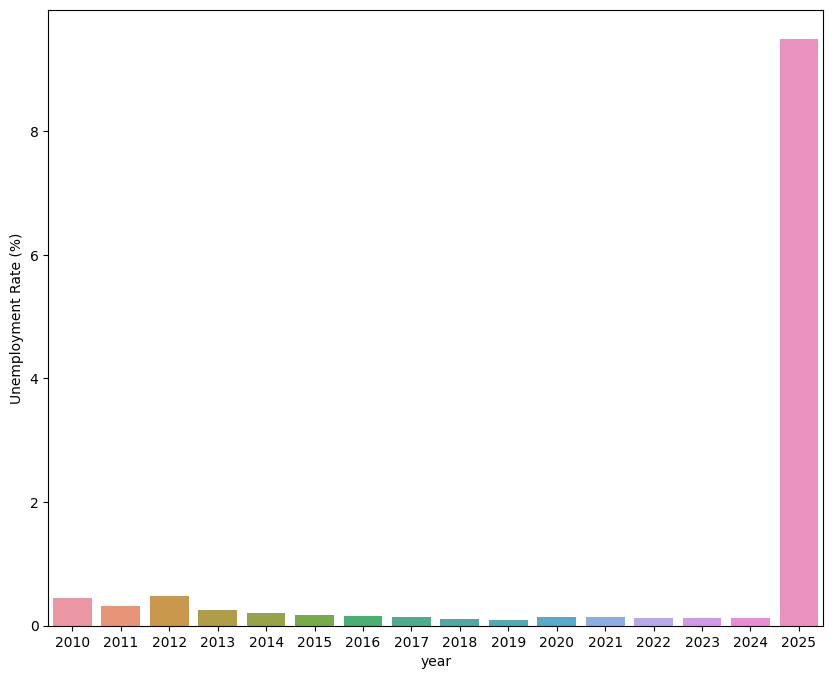

In [21]:
plt.figure(figsize=(10,8))
sns.barplot(data=df3 , x='year' , y='Unemployment Rate (%)' , estimator=sum)
plt.show()

In [22]:
df4 = df.loc[df.groupby('year')['GDP Growth (% Annual)'].idxmax()]
df4

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Gross National Income (USD)
1888,"Macao SAR, China",mo,2010,2.809472,2.824180e+10,52591.803523,2.840,0.438440,4.790556,25.122809,38.919861,2.490955e+10
1889,"Macao SAR, China",mo,2011,5.806246,3.684589e+10,67041.282309,2.560,-2.084465,7.490604,21.616690,40.380521,3.153944e+10
1762,Libya,ly,2012,6.059804,9.254094e+10,14975.890280,19.030,0.017050,5.981931,86.826748,25.757573,9.061158e+10
2755,Sierra Leone,sl,2013,5.524129,7.697098e+09,1146.416391,4.538,12.715930,6.959150,21.079014,-9.576278,7.696662e+09
2356,Nauru,nr,2014,8.930000,9.875226e+07,9193.097844,9.490,3.480000,0.427699,16.423336,26.358379,1.213873e+08
1445,Ireland,ie,2015,-0.330960,3.023914e+11,64311.823468,9.908,3.480000,8.908451,24.615570,6.166118,2.251978e+11
2134,Northern Mariana Islands,mp,2016,8.930000,1.230000e+09,24225.474169,9.490,3.480000,4.606932,29.212121,-3.240000,1.323759e+10
1767,Libya,ly,2017,25.803618,6.715745e+10,9965.832367,19.020,3.480000,1.806664,32.491802,6.591078,6.843954e+10
1640,Cambodia,kh,2018,2.459085,3.314589e+10,2036.673776,0.130,3.480000,3.816581,8.776224,-8.735823,3.182017e+10
3097,Timor-Leste,tl,2019,0.958813,2.032550e+09,1562.364589,3.097,9.697111,5.164283,24.212884,26.381513,2.869484e+09


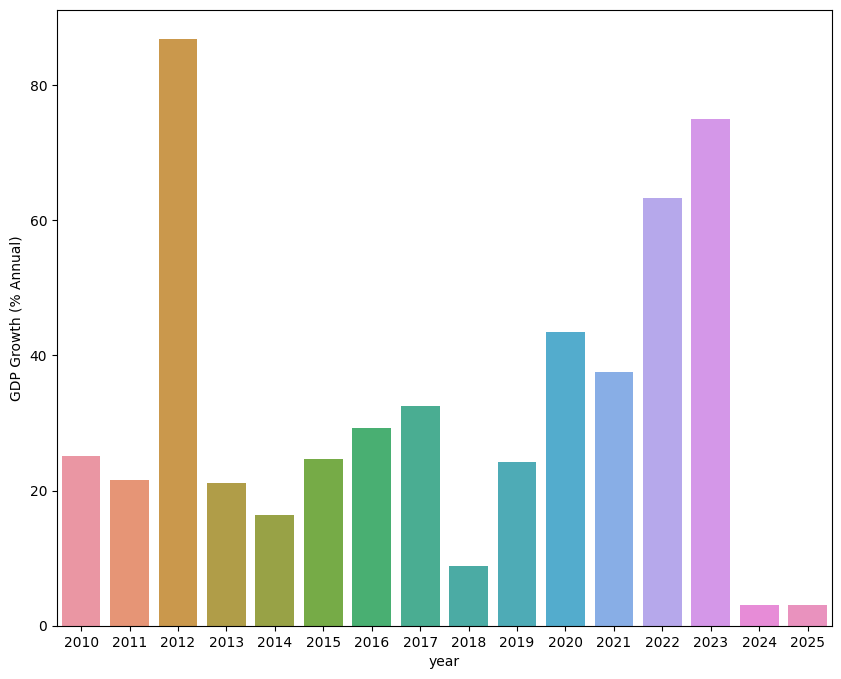

In [23]:
plt.figure(figsize=(10,8))
sns.barplot(data=df4 , x='year' , y='GDP Growth (% Annual)' , estimator=sum)
plt.show()